<a href="https://colab.research.google.com/github/annabashlakova/ECON3916-Statistical-Machine-Learning/blob/main/Lab_8_Hypothesis_Testing_%E2%80%94_The_Architecture_of_Evidence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
# Load Data
df = pd.read_csv('lalonde copy.csv')

# Split Groups
treated = df[df['treat']== 1]['re78']
control = df[df['treat']== 0]['re78']

# Inspect the raw means
print(f"Mean Treated: ${treated.mean():.2f}")
print(f"Mean Control: ${control.mean():.2f}")

Mean Treated: $6349.14
Mean Control: $6984.17


In [4]:
# Calculate Signal
signal = treated.mean() - control.mean()

# T-Test
t_stat, p_val = stats.ttest_ind(treated, control, equal_var=False)

print(f"Treatment Effect (Signal): ${signal:.2f}")
print(f"T-Statistic (Signal/Noise): {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

# Decision Rule
if p_val < 0.05:
    print("Reject Null: The training has a statistically significant effect.")
else:
    print("Fail to Reject Null: Result could be due to chance.")

Treatment Effect (Signal): $-635.03
T-Statistic (Signal/Noise): -0.9377
P-Value: 0.3491
Fail to Reject Null: Result could be due to chance.


In [5]:
# Define the Function
def difference_in_means(x, y):
  return np.mean(x) - np.mean(y)

# Permutation Test

res = stats.permutation_test((treated, control), difference_in_means,
                             permutation_type='independent',
                             n_resamples=10000,
                             alternative='two-sided')

print(f"Permutation P-Value: {res.pvalue:.4f}")
print("compare this to your T-test P-value. Are they consistent?")

Permutation P-Value: 0.3280
compare this to your T-test P-value. Are they consistent?


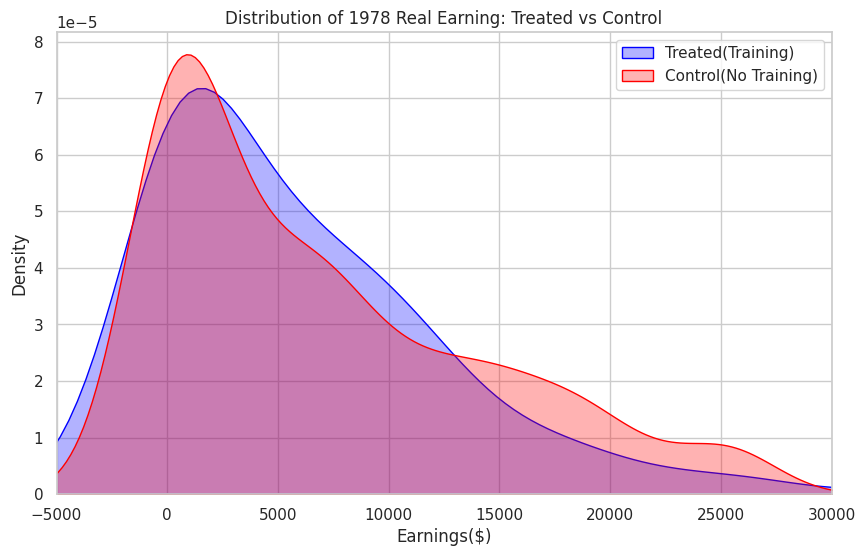

In [6]:
# Visualize the distribution
plt.figure(figsize=(10, 6))

# Plot kernel Density Estimate
sns.kdeplot(treated,fill=True, label='Treated(Training)', color='blue', alpha=0.3)
sns.kdeplot(control, fill=True, label='Control(No Training)', color='red', alpha=0.3)

plt.title('Distribution of 1978 Real Earning: Treated vs Control')
plt.xlabel('Earnings($)')
plt.xlim(-5000, 30000)
plt.legend()
plt.show()